# Assignment 2

## Problem 1

### 1.1 Implement Gillespies algorithm

In [1]:
# Import libraries:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


In [2]:
# Define initial values, events and rates

# Initial population
N0 = 100000

# Initial conditions
Y = 10
Z = 0
X = N0 - Y - Z

# Parameters measured in days
beta = 0.3
gamma = 0.1
mu = 1 / (80 * 365)

# Initial time
t = 0

# Simulation time
t_max = 365  # 1 year

# Store the state after each event
times = [t]
X_values = [X]
Y_values = [Y]
Z_values = [Z]

In [3]:

while t < t_max:
    
    # Step 2: Calculate rates
    N = X + Y + Z

    rate_birth = mu * N
    rate_transmission = beta * X * Y / N
    rate_recovery = gamma * Y
    rate_death_X = mu * X
    rate_death_Y = mu * Y
    rate_death_Z = mu * Z

    # Step 3: Total rate
    R_total = (
        rate_birth
        + rate_transmission
        + rate_recovery
        + rate_death_X
        + rate_death_Y
        + rate_death_Z
    )

    # Step 4: Waiting time
    RAND_1 = np.random.rand()
    ## Determines when the next event happens

    delta_t = -np.log(RAND_1) / R_total

    # Step 5: Draw random number for event selection
    RAND_2 = np.random.rand()
    ## Determines which event happens next

    # Define P
    P = RAND_2 * R_total

    # Step 6: Select event
    cumulative_rates = np.cumsum([
        rate_birth,
        rate_transmission,
        rate_recovery,
        rate_death_X,
        rate_death_Y,
        rate_death_Z
    ])

    if P <= cumulative_rates[0]:
        event = 0

    elif P > cumulative_rates[0] and P <= cumulative_rates[1]:
        event = 1

    elif P > cumulative_rates[1] and P <= cumulative_rates[2]:
        event = 2

    elif P > cumulative_rates[2] and P <= cumulative_rates[3]:
        event = 3

    elif P > cumulative_rates[3] and P <= cumulative_rates[4]:
        event = 4

    else:
        event = 5

    # Step 7: Update time
    t += delta_t

    # Perform event
    if event == 0:
        X += 1

    elif event == 1:
        X -= 1
        Y += 1

    elif event == 2:
        Y -= 1
        Z += 1

    elif event == 3:
        X -= 1

    elif event == 4:
        Y -= 1

    elif event == 5:
        Z -= 1

    # Store the new state
    times.append(t)
    X_values.append(X)
    Y_values.append(Y)
    Z_values.append(Z)



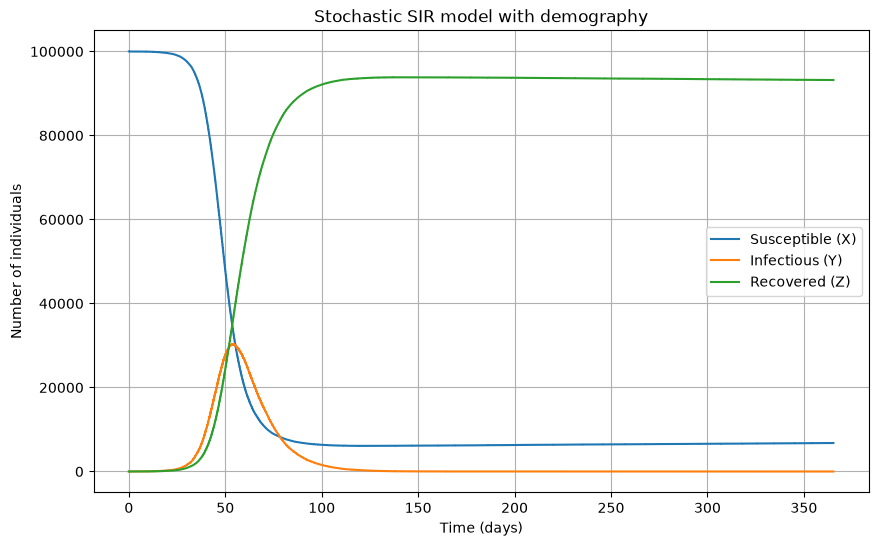

In [4]:
# Plot the Gillespie algorithm:

plt.figure(figsize=(10, 6))

plt.step(times, X_values, label="Susceptible (X)")
plt.step(times, Y_values, label="Infectious (Y)")
plt.step(times, Z_values, label="Recovered (Z)")

plt.xlabel("Time (days)")
plt.ylabel("Number of individuals")
plt.title("Stochastic SIR model with demography")
plt.legend()
plt.grid()

plt.show()

#### Compare the GA Stochastic Simulation with an Equivalent Deterministic ODE Model

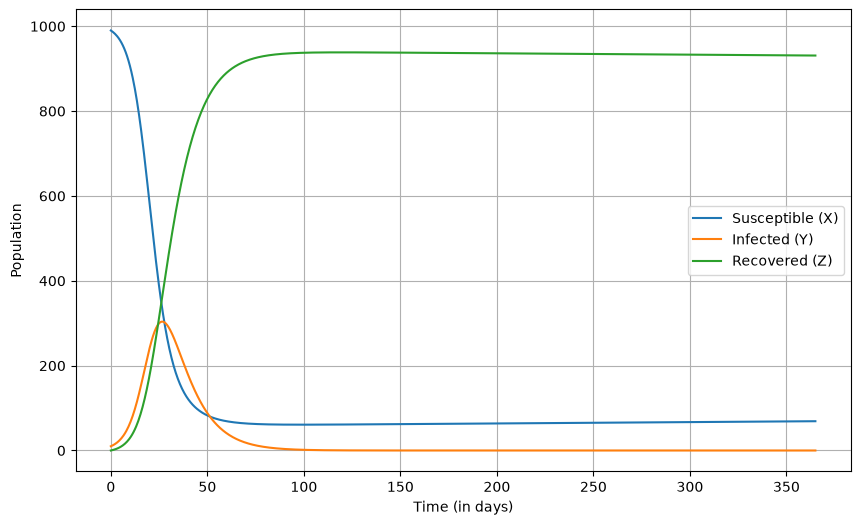

In [5]:
# Using the same initial values, events and rates

# Initial population
N0 = 1000

# Initial conditions
Y = 10
Z = 0
X = N0 - Y - Z
y0 = [X, Y, Z]

# Parameters measured in days
beta = 0.3
gamma = 0.1
mu = 1 / (80 * 365)

# Time - 1 year 
t = np.linspace(0,365,1000)


def model(y, t, beta, gamma, u):
    s, i, r = y
    N = s + i + r
    dsdt = u*N - beta*s*i/N - u*s
    didt = beta*s*i/N - gamma*i - u*i
    drdt = gamma*i - u*r
    return [dsdt, didt, drdt]

# Numerically integrate the ODE
solution = odeint(model, y0, t, args=(beta, gamma, mu))

s, i, r = solution.T

plt.figure(figsize=(10, 6))
plt.plot(t, s, label="Susceptible (X)")
plt.plot(t, i, label="Infected (Y)")
plt.plot(t, r, label="Recovered (Z)")
plt.xlabel("Time (in days)")
plt.ylabel("Population")
plt.legend()
plt.grid()
plt.show()

Both graphs have the same overall shape, with small differences that come from chance from the stochastic model since it shows one possible version of the epidemic, while the ODE describes the average.

#### Bonus - Control the noise level in the GA

A way to control the noise level in the GA is to make the population size larger, since the randomness from the stochasticity will be less noticable. In the report, explain how, why and insert a plot with a larger population.

### 1.2 Investigate Simulation Variability and Negative Covariance

In [6]:
# Define initial values and rates

# Population sizes to compare
N0_vary = [100, 500, 1000, 2000, 5000, 10000, 50000]

# Parameters measured in days
beta = 0.3
gamma = 0.1
mu = 1 / (80 * 365)

# Simulation time
t_max = 365  # 1 year

[99, 495, 990, 1980, 4950, 9900, 49500] [1, 5, 10, 20, 50, 100, 500] [0, 0, 0, 0, 0, 0, 0]


In [7]:
def simulation_variability(t, X, Y, Z, beta=beta):
    # Store the state after each event
    times = [t]
    X_values = [X]
    Y_values = [Y]
    Z_values = [Z]

    while t < t_max:
        
        # Step 2: Calculate rates
        N = X + Y + Z

        rate_birth = mu * N
        rate_transmission = beta * X * Y / N
        rate_recovery = gamma * Y
        rate_death_X = mu * X
        rate_death_Y = mu * Y
        rate_death_Z = mu * Z

        # Step 3: Total rate
        R_total = (
            rate_birth
            + rate_transmission
            + rate_recovery
            + rate_death_X
            + rate_death_Y
            + rate_death_Z
        )

        # Step 4: Waiting time
        RAND_1 = np.random.rand()
        ## Determines when the next event happens

        delta_t = -np.log(RAND_1) / R_total

        # Step 5: Draw random number for event selection
        RAND_2 = np.random.rand()
        ## Determines which event happens next

        # Define P
        P = RAND_2 * R_total

        # Step 6: Select event
        cumulative_rates = np.cumsum([
            rate_birth,
            rate_transmission,
            rate_recovery,
            rate_death_X,
            rate_death_Y,
            rate_death_Z
        ])

        if P <= cumulative_rates[0]:
            event = 0

        elif P > cumulative_rates[0] and P <= cumulative_rates[1]:
            event = 1

        elif P > cumulative_rates[1] and P <= cumulative_rates[2]:
            event = 2

        elif P > cumulative_rates[2] and P <= cumulative_rates[3]:
            event = 3

        elif P > cumulative_rates[3] and P <= cumulative_rates[4]:
            event = 4

        else:
            event = 5

        # Step 7: Update time
        t += delta_t

        # Perform event
        if event == 0:
            X += 1

        elif event == 1:
            X -= 1
            Y += 1

        elif event == 2:
            Y -= 1
            Z += 1

        elif event == 3:
            X -= 1

        elif event == 4:
            Y -= 1

        elif event == 5:
            Z -= 1

        # Store the new state
        times.append(t)
        X_values.append(X)
        Y_values.append(Y)
        Z_values.append(Z)
    return times, X_values, Y_values, Z_values


In [9]:
times_1000, X_values_1000, Y_values_1000, Z_values_1000 = simulation_variability(0, 990, 10, 0, beta=0.3)

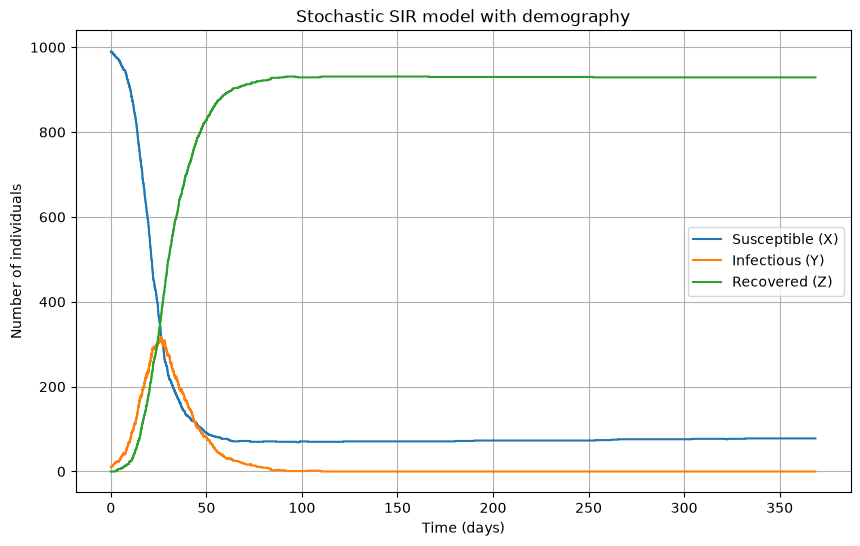

In [10]:
# Plot the Gillespie algorithm:

plt.figure(figsize=(10, 6))

plt.step(times_1000, X_values_1000, label="Susceptible (X)")
plt.step(times_1000, Y_values_1000, label="Infectious (Y)")
plt.step(times_1000, Z_values_1000, label="Recovered (Z)")

plt.xlabel("Time (days)")
plt.ylabel("Number of individuals")
plt.title("Stochastic SIR model with demography")
plt.legend()
plt.grid()

plt.show()

In [11]:
def run_simulations(N0, beta, Y0=None, n_runs=200):

    if Y0 is None:
        Y0 = 0.01 * N0

    all_simulations = []

    for i in range(n_runs):

        times, X_values, Y_values, Z_values = simulation_variability(
            0, N0 - Y0, Y0, 0, beta=beta
        )

        all_simulations.append(
            (np.array(times), np.array(X_values), np.array(Y_values), np.array(Z_values))
        )

    return all_simulations



def calculate_statistics(all_simulations):

    # Common time points: every day from 0 to 365
    time_grid = np.arange(0, 366)

    X_runs = []
    Y_runs = []
    Z_runs = []

    # Put every simulation onto the same time grid
    for times, X_values, Y_values, Z_values in all_simulations:

        indices = np.searchsorted(times, time_grid, side="right") - 1

        X_runs.append(X_values[indices])
        Y_runs.append(Y_values[indices])
        Z_runs.append(Z_values[indices])

    # Convert to arrays
    X_runs = np.array(X_runs)
    Y_runs = np.array(Y_runs)
    Z_runs = np.array(Z_runs)

    # Mean at each time point
    X_mean = np.mean(X_runs, axis=0)
    Y_mean = np.mean(Y_runs, axis=0)
    Z_mean = np.mean(Z_runs, axis=0)

    # Variance at each time point
    X_var = np.var(X_runs, axis=0)
    Y_var = np.var(Y_runs, axis=0)
    Z_var = np.var(Z_runs, axis=0)

    # Covariance between X and Y at each time point
    XY_cov = np.mean(
        (X_runs - X_mean) * (Y_runs - Y_mean),
        axis=0
    )

    return (
        time_grid,
        X_mean, Y_mean, Z_mean,
        X_var, Y_var, Z_var,
        XY_cov
    )



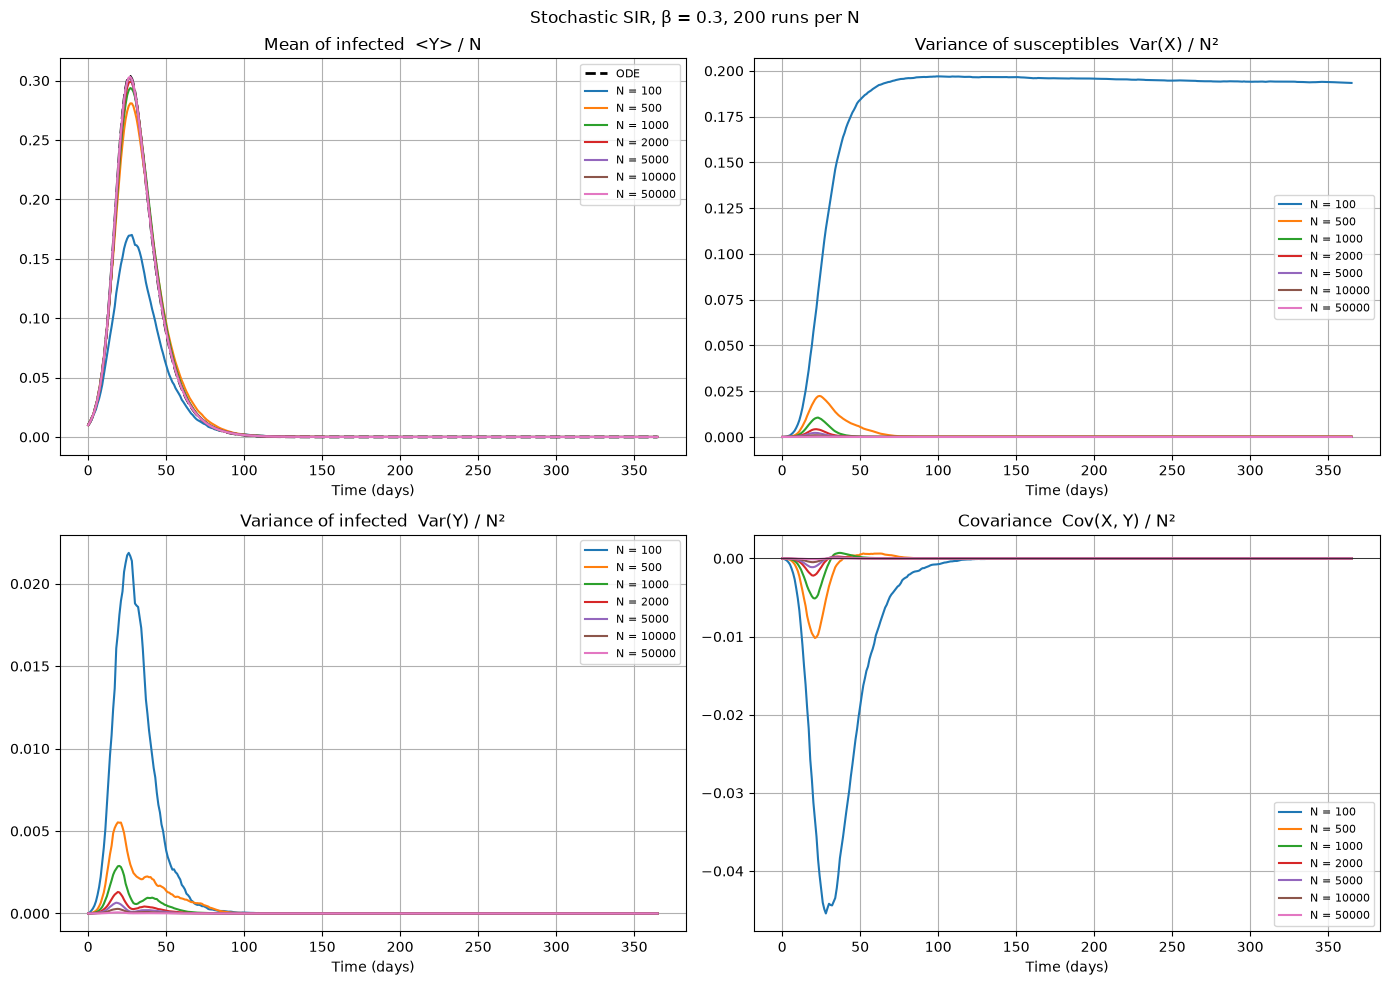

In [15]:
# Mean, variance and covariance for every population size N, with beta = 0.3
# Values are divided by N (mean) and N^2 (variance, covariance) so the scenarios can be compared on one plot

beta_fixed = 0.3

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax_mean, ax_varX, ax_varY, ax_cov = axes.flatten()

# Deterministic ODE solution (as a fraction of N it is the same for every N, since Y0 = 1% of N)
ode_time = np.arange(0, 366)
ode_solution = odeint(model, [0.99, 0.01, 0], ode_time, args=(beta_fixed, gamma, mu))
ax_mean.plot(ode_time, ode_solution[:, 1], "k--", lw=2, label="ODE")

for N0 in N0_vary:
    simulations = run_simulations(N0, beta_fixed)
    time_grid, X_mean, Y_mean, Z_mean, X_var, Y_var, Z_var, XY_cov = calculate_statistics(simulations)

    ax_mean.plot(time_grid, Y_mean / N0, label=f"N = {N0}")
    ax_varX.plot(time_grid, X_var / N0**2, label=f"N = {N0}")
    ax_varY.plot(time_grid, Y_var / N0**2, label=f"N = {N0}")
    ax_cov.plot(time_grid, XY_cov / N0**2, label=f"N = {N0}")

ax_mean.set_title("Mean of infected  <Y> / N")
ax_varX.set_title("Variance of susceptibles  Var(X) / N²")
ax_varY.set_title("Variance of infected  Var(Y) / N²")
ax_cov.set_title("Covariance  Cov(X, Y) / N²")
ax_cov.axhline(0, color="k", lw=0.5)

for ax in axes.flatten():
    ax.set_xlabel("Time (days)")
    ax.grid()
    ax.legend(fontsize=8)

fig.suptitle(f"Stochastic SIR, β = {beta_fixed}, 200 runs per N")
plt.tight_layout()
plt.show()


#### Beta variance

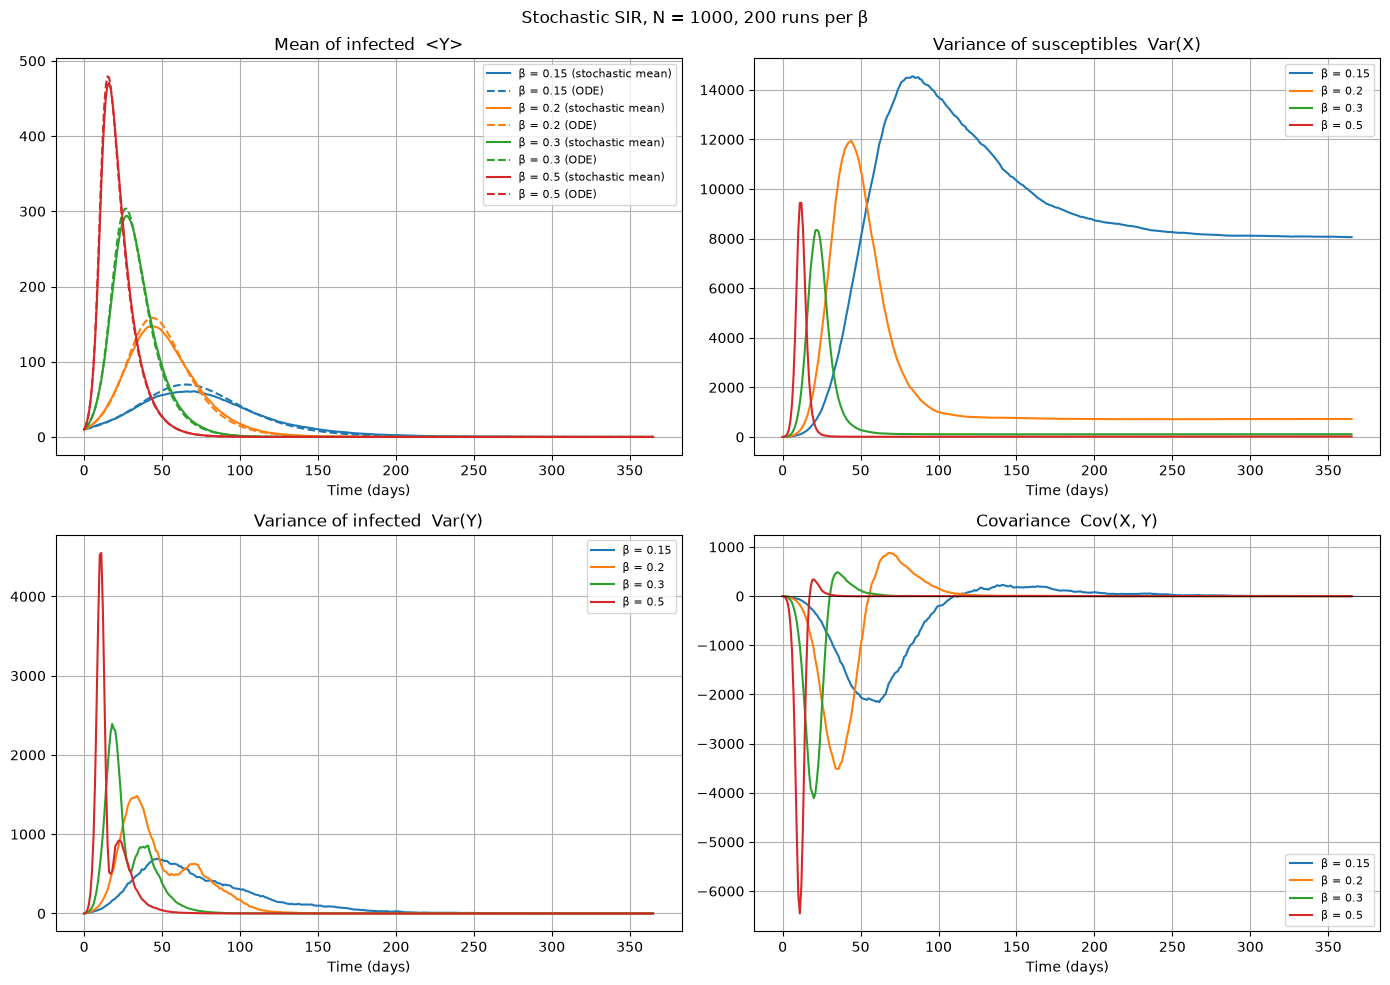

In [31]:
# Mean, variance and covariance for different values of beta, with N = 1000
# The mean is compared with the deterministic ODE solution for the same beta

N_fixed = 1000
beta_vary = [0.15, 0.2, 0.3, 0.5]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax_mean, ax_varX, ax_varY, ax_cov = axes.flatten()

ode_time = np.arange(0, 366)

for beta_i in beta_vary:
    simulations = run_simulations(N_fixed, beta_i)
    time_grid, X_mean, Y_mean, Z_mean, X_var, Y_var, Z_var, XY_cov = calculate_statistics(simulations)

    # Deterministic ODE solution for the same beta
    ode_solution = odeint(model, [0.99 * N_fixed, 0.01 * N_fixed, 0], ode_time, args=(beta_i, gamma, mu))

    line, = ax_mean.plot(time_grid, Y_mean, label=f"β = {beta_i} (stochastic mean)")
    ax_mean.plot(ode_time, ode_solution[:, 1], "--", color=line.get_color(), label=f"β = {beta_i} (ODE)")
    ax_varX.plot(time_grid, X_var, label=f"β = {beta_i}")
    ax_varY.plot(time_grid, Y_var, label=f"β = {beta_i}")
    ax_cov.plot(time_grid, XY_cov, label=f"β = {beta_i}")

ax_mean.set_title("Mean of infected  <Y>")
ax_varX.set_title("Variance of susceptibles  Var(X)")
ax_varY.set_title("Variance of infected  Var(Y)")
ax_cov.set_title("Covariance  Cov(X, Y)")
ax_cov.axhline(0, color="k", lw=0.5)

for ax in axes.flatten():
    ax.set_xlabel("Time (days)")
    ax.grid()
    ax.legend(fontsize=8)

fig.suptitle(f"Stochastic SIR, N = {N_fixed}, 200 runs per β")
plt.tight_layout()
plt.show()

### 1.3 Stochastic Resonance and Increased Transients

### 1.4 Extinction events and Critical Community Size

#### Experiment for extinction varying R_0

In [16]:

def extinction_simulation(N0, beta, gamma=0.1, mu=1/(80*365),
                          threshold_fraction=0.10):

    # Initial conditions
    X = N0 - 1
    Y = 1
    Z = 0

    # Time
    t = 0

    # Count cumulative infections
    cumulative_infections = 1

    threshold = threshold_fraction * N0

    while Y > 0 and cumulative_infections < threshold:

        # Current population size
        N = X + Y + Z

        # Rates
        rate_birth = mu * N
        rate_transmission = beta * X * Y / N
        rate_recovery = gamma * Y
        rate_death_X = mu * X
        rate_death_Y = mu * Y
        rate_death_Z = mu * Z

        rates = [
            rate_birth,
            rate_transmission,
            rate_recovery,
            rate_death_X,
            rate_death_Y,
            rate_death_Z
        ]

        R_total = sum(rates)

        # Waiting time
        RAND_1 = np.random.rand()
        delta_t = -np.log(RAND_1) / R_total

        t += delta_t

        # Select event
        RAND_2 = np.random.rand()
        P = RAND_2 * R_total

        cumulative_rates = np.cumsum(rates)

        if P <= cumulative_rates[0]:
            # Birth
            X += 1

        elif P > cumulative_rates[0] and P <= cumulative_rates[1]:
            # Transmission
            X -= 1
            Y += 1
            cumulative_infections += 1

        elif  P > cumulative_rates[1] and P <= cumulative_rates[2]:
            # Recovery
            Y -= 1
            Z += 1

        elif P > cumulative_rates[2] and P <= cumulative_rates[3]:
            # Death of susceptible
            X -= 1

        elif P > cumulative_rates[3] and P <= cumulative_rates[4]:
            # Death of infected
            Y -= 1

        else:
            # Death of recovered
            Z -= 1

    # Determine outcome
    if Y == 0:
        outcome = "extinction"

    elif cumulative_infections >= threshold:
        outcome = "major_epidemic"

    return outcome, t, cumulative_infections


In [17]:
# Different teoretical R_0 values we will simulate over:

beta_values = [0.15, 0.20, 0.30, 0.50]

for beta in beta_values:

    R0 = beta / (gamma + mu)

    print("beta =", beta, "R0 =", R0)

beta = 0.15 R0 = 1.4994864772338239
beta = 0.2 R0 = 1.999315302978432
beta = 0.3 R0 = 2.9989729544676478
beta = 0.5 R0 = 4.99828825744608


In [18]:
# Run simulations:

n_simulations = 1000

results = {}

for beta in beta_values:

    outcomes = []

    for i in range(n_simulations):

        outcome, t, infections = extinction_simulation(
            N0=1000,
            beta=beta
        )

        outcomes.append(outcome)

    results[beta] = outcomes

In [19]:
# calculate the empirical extinction probability

extinction_probabilities = []

for beta in beta_values:

    outcomes = results[beta]

    extinction_probability = outcomes.count("extinction") / n_simulations

    extinction_probabilities.append(extinction_probability)

# Calculate the teoretical extinction probability (from Keeling and Rohani, ch. 6)

theoretical_probabilities = []

for beta in beta_values:

    R0 = beta / (gamma + mu)

    theoretical_probability = 1 / R0

    theoretical_probabilities.append(theoretical_probability)

In [20]:
# Make a results table and a plot

results_df = pd.DataFrame({
    "beta": beta_values,
    "R0": [beta / (gamma + mu) for beta in beta_values],
    "Empirical P_ext": extinction_probabilities,
    "Theoretical P_ext": theoretical_probabilities
})

results_df

,beta,R0,Empirical P_ext,Theoretical P_ext
0,0.15,1.499486,0.654,0.666895
1,0.20,1.999315,0.524,0.500171
2,0.30,2.998973,0.329,0.333447
3,0.50,4.998288,0.197,0.200068


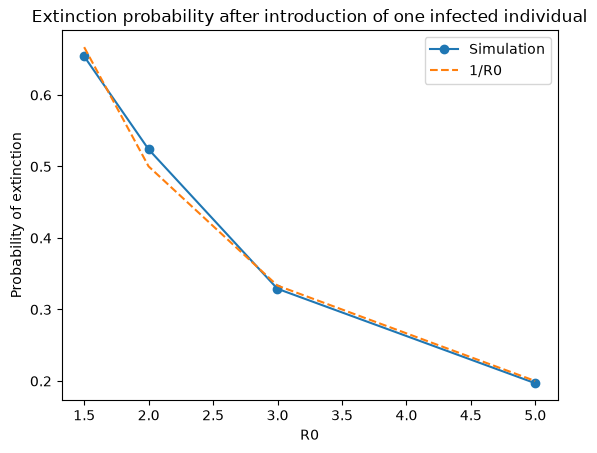

In [21]:
plt.plot(
    results_df["R0"],
    results_df["Empirical P_ext"],
    "o-",
    label="Simulation"
)

plt.plot(
    results_df["R0"],
    results_df["Theoretical P_ext"],
    "--",
    label="1/R0"
)

plt.xlabel("R0")
plt.ylabel("Probability of extinction")
plt.title("Extinction probability after introduction of one infected individual")
plt.legend()
plt.show()

We see that even when R_0>1, a newly introduced infection can go extinct purely due to stochasticity (the randomness). In this experiment, we are testing whether the infection goes extinct before it establishes a major epidemic, we are therefore not including the point that in a closed system the infeection will go extinct eventually.

The probability of stochastic extinction decreases as R_0 increases. The simulation results are close to the theoretical extinction probability P_ext = 1/R_0. This shows that even when R_0>1, an infection introduced by a single infected individual can go extinct due to stochastic effects before causing a major epidemic.

#### Experiment for extinction varying N: Maybe change t_max to 150!!!

In [22]:
def long_term_extinction_simulation(N0, beta, gamma=0.1,
                                    mu=1/(80*365), t_max=100):

    # Initial conditions
    X = int(0.99 * N0)
    Y = int(0.01 * N0)
    Z = 0

    t = 0

    while t < t_max and Y > 0:

        # Current population size
        N = X + Y + Z

        # Rates
        rate_birth = mu * N
        rate_transmission = beta * X * Y / N
        rate_recovery = gamma * Y
        rate_death_X = mu * X
        rate_death_Y = mu * Y
        rate_death_Z = mu * Z

        rates = [
            rate_birth,
            rate_transmission,
            rate_recovery,
            rate_death_X,
            rate_death_Y,
            rate_death_Z
        ]

        R_total = sum(rates)

        # Waiting time
        RAND_1 = np.random.rand()
        delta_t = -np.log(RAND_1) / R_total

        t += delta_t

        # Select event
        RAND_2 = np.random.rand()
        P = RAND_2 * R_total

        cumulative_rates = np.cumsum(rates)

        if P <= cumulative_rates[0]:
            # Birth
            X += 1

        elif P > cumulative_rates[0] and P <= cumulative_rates[1]:
            # Transmission
            X -= 1
            Y += 1

        elif P > cumulative_rates[1] and P <= cumulative_rates[2]:
            # Recovery
            Y -= 1
            Z += 1

        elif P > cumulative_rates[2] and P <= cumulative_rates[3]:
            # Death of susceptible
            X -= 1

        elif P > cumulative_rates[3] and P <= cumulative_rates[4]:
            # Death of infected
            Y -= 1

        else:
            # Death of recovered
            Z -= 1

    # Determine outcome
    if Y == 0:
        outcome = "extinction"
    else:
        outcome = "not_extinct"

    return outcome, t

In [23]:
# Run simulations when varying N:

N_values = [100, 500, 1000, 5000, 10000, 50000]

n_simulations = 200

N_results = {}

for N0 in N_values:

    outcomes = []

    for i in range(n_simulations):

        outcome, t = long_term_extinction_simulation(
            N0=N0,
            beta=0.3
        )

        outcomes.append(outcome)

    N_results[N0] = outcomes

In [24]:
extinction_probabilities_N = []

for N0 in N_values:

    outcomes = N_results[N0]

    extinction_probability = outcomes.count("extinction") / n_simulations

    extinction_probabilities_N.append(extinction_probability)

In [25]:
# Make a results table:

N_results_df = pd.DataFrame({
    "N": N_values,
    "Extinction probability": extinction_probabilities_N
})

N_results_df

,N,Extinction probability
0,100,0.960
1,500,0.725
2,1000,0.360
3,5000,0.000
4,10000,0.000
5,50000,0.000


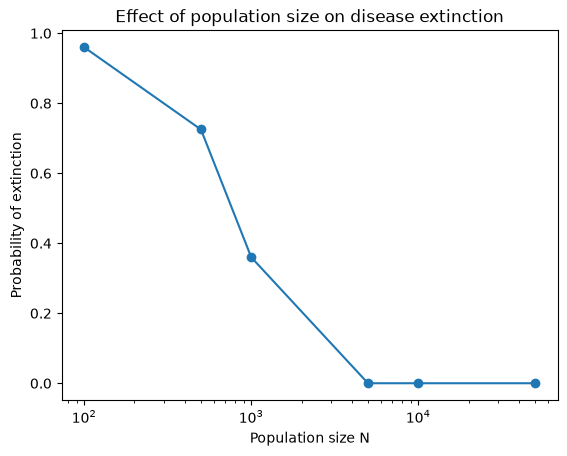

In [26]:
# Make a plot of the results:

plt.plot(
    N_results_df["N"],
    N_results_df["Extinction probability"],
    "o-"
)

plt.xlabel("Population size N")
plt.ylabel("Probability of extinction")
plt.title("Effect of population size on disease extinction")
plt.xscale("log")
plt.show()

#### Experiment for extinction varying both N and R_0 and look at interaction:

In [27]:
# Run simulations when varying both:

n_simulations = 200

interaction_results = []

for N0 in N_values:

    for beta in beta_values:

        outcomes = []

        for i in range(n_simulations):

            outcome, t = long_term_extinction_simulation(
                N0=N0,
                beta=beta
            )

            outcomes.append(outcome)

        extinction_probability = (
            outcomes.count("extinction") / n_simulations
        )

        R0 = beta / (gamma + mu)

        interaction_results.append({
            "N": N0,
            "beta": beta,
            "R0": R0,
            "extinction_probability": extinction_probability
        })

In [28]:
# Make a dataframe with the results:

interaction_df = pd.DataFrame(interaction_results)

interaction_df

,N,beta,R0,extinction_probability
0,100,0.15,1.499486,0.840
1,100,0.20,1.999315,0.845
2,100,0.30,2.998973,0.975
3,100,0.50,4.998288,0.995
4,500,0.15,1.499486,0.155
5,500,0.20,1.999315,0.085
6,500,0.30,2.998973,0.660
7,500,0.50,4.998288,0.965
8,1000,0.15,1.499486,0.010
9,1000,0.20,1.999315,0.015


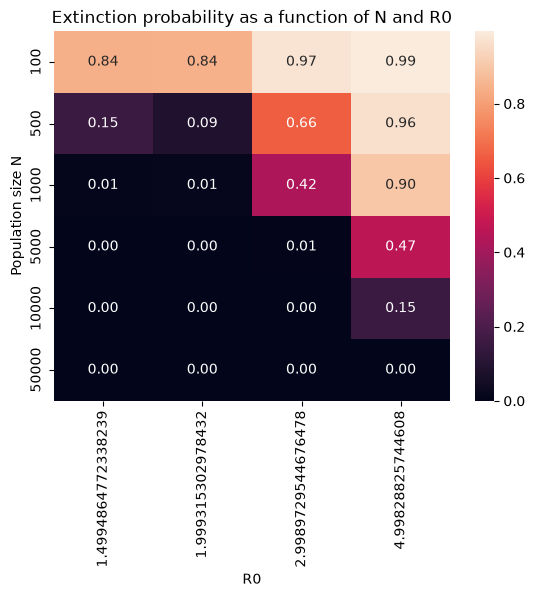

In [30]:
# Make a heatmap showing the interaction between N and R_0 in regards to impacting the extinction process:

import seaborn as sns

heatmap_data = interaction_df.pivot(
    index="N",
    columns="R0",
    values="extinction_probability"
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f"
)

plt.xlabel("R0")
plt.ylabel("Population size N")
plt.title("Extinction probability as a function of N and R0")
plt.show()